## 1. IMPORT

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve
)
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
import warnings
warnings.filterwarnings('ignore')

## 2. ĐỌC DỮ LIỆU

In [2]:
customer = pd.read_csv('../data/customer.csv')
df_success = pd.read_csv('../data/df_success.csv')
df_success['InvoiceDate'] = pd.to_datetime(df_success['InvoiceDate'])

print(f"Tổng số khách hàng: {len(customer)}")
print(f"Tổng số giao dịch: {len(df_success)}")

Tổng số khách hàng: 4314
Tổng số giao dịch: 407695


## 3. TẠO FEATURE (6 THÁNG ĐẦU)
Lấy 6 tháng đầu tiên của mỗi khách để tạo feature, 6 tháng cuối dùng để xác định nhãn churn (giống logic ở phase trước).

In [3]:
now = df_success['InvoiceDate'].max() + pd.Timedelta(days=1)
six_months_ago = now - pd.Timedelta(days=180)

first_6_months = df_success[df_success['InvoiceDate'] < six_months_ago]

In [4]:
# RFM + features hành vi mua hàng
rfm_features = first_6_months.groupby('Customer ID').agg({
    'InvoiceDate': [
        lambda x: (now - x.max()).days,      # Recency
        lambda x: (x.max() - x.min()).days,  # thời gian gắn bó (lifespan)
        lambda x: x.nunique()                # số ngày mua khác nhau
    ],
    'Invoice': 'nunique',                     # Frequency
    'Amount': ['sum', 'mean', 'std'],         # Monetary
    'Quantity': ['sum', 'mean', 'std'],
    'Price': ['mean', 'std'],
    'StockCode': 'nunique'                    # độ đa dạng sản phẩm mua
})

In [5]:
rfm_features.columns = [
    'Recency', 'Lifespan', 'Unique_Dates',
    'Frequency',
    'Monetary_Sum', 'Monetary_Mean', 'Monetary_Std',
    'Quantity_Sum', 'Quantity_Mean', 'Quantity_Std',
    'Price_Mean', 'Price_Std',
    'Unique_Products'
]

In [6]:
# khoảng cách giữa các lần mua (đều đặn hay thất thường)
first_6_months_sorted = first_6_months.sort_values(['Customer ID', 'InvoiceDate'])
first_6_months_sorted['Prev_Date'] = first_6_months_sorted.groupby('Customer ID')['InvoiceDate'].shift(1)
first_6_months_sorted['Days_Between'] = (first_6_months_sorted['InvoiceDate'] - first_6_months_sorted['Prev_Date']).dt.days

avg_days_between = first_6_months_sorted.groupby('Customer ID')['Days_Between'].agg(['mean', 'std', 'min', 'max'])
avg_days_between.columns = ['Avg_Days_Between', 'Std_Days_Between', 'Min_Days_Between', 'Max_Days_Between']

In [7]:
X = rfm_features.join(avg_days_between, how='left')

In [8]:
# khách chỉ mua đúng 1 lần trong 6 tháng đầu sẽ bị NaN ở mấy khoảng cách -> gán 365 ngày (coi như rất lâu chưa mua lại)
X['Avg_Days_Between'] = X['Avg_Days_Between'].fillna(365)
X['Std_Days_Between'] = X['Std_Days_Between'].fillna(0)
X['Min_Days_Between'] = X['Min_Days_Between'].fillna(365)
X['Max_Days_Between'] = X['Max_Days_Between'].fillna(365)
X['Monetary_Std'] = X['Monetary_Std'].fillna(0)
X['Quantity_Std'] = X['Quantity_Std'].fillna(0)
X['Price_Std'] = X['Price_Std'].fillna(0)

print(f"Số features đã tạo: {X.shape[1]}")

Số features đã tạo: 17


## 4. TẠO TARGET (CHURN)

In [9]:
last_6_months = df_success[df_success['InvoiceDate'] >= six_months_ago]
active_customers = set(last_6_months['Customer ID'].unique())

In [10]:
# Churn = 1 nếu 6 tháng cuối không mua lại, 0 nếu có mua lại
y = pd.Series(
    [1 if idx not in active_customers else 0 for idx in X.index],
    index=X.index,
    name='Churn'
)

churn_rate = y.mean()
print(f"Tỷ lệ churn: {churn_rate*100:.1f}%")
print(f"  - Churn (không mua lại): {(y == 1).sum()}")
print(f"  - Active (có mua lại): {(y == 0).sum()}")

Tỷ lệ churn: 29.4%
  - Churn (không mua lại): 833
  - Active (có mua lại): 1997


## 5. EDA - PHÂN TÍCH KHÁM PHÁ

In [11]:
churn_stats = X.join(y).groupby('Churn').mean().T
churn_stats.columns = ['Active (0)', 'Churn (1)']
churn_stats['Diff_%'] = (churn_stats['Churn (1)'] - churn_stats['Active (0)']) / churn_stats['Active (0)'] * 100

churn_stats.sort_values('Diff_%', ascending=False).head(10)

,Active (0),Churn (1),Diff_%
Price_Mean,3.636073,28.884892,694.398116
Min_Days_Between,5.538307,20.284514,266.258355
Avg_Days_Between,7.199060,21.293409,195.780416
Monetary_Mean,31.521159,56.272474,78.522856
Recency,234.260391,264.427371,12.877542
Quantity_Mean,22.018707,23.968638,8.855791
Quantity_Std,17.808520,17.537861,-1.519826
Price_Std,4.083602,3.866927,-5.305985
Max_Days_Between,48.200300,38.996399,-19.095113
Monetary_Std,21.604868,17.252799,-20.143930


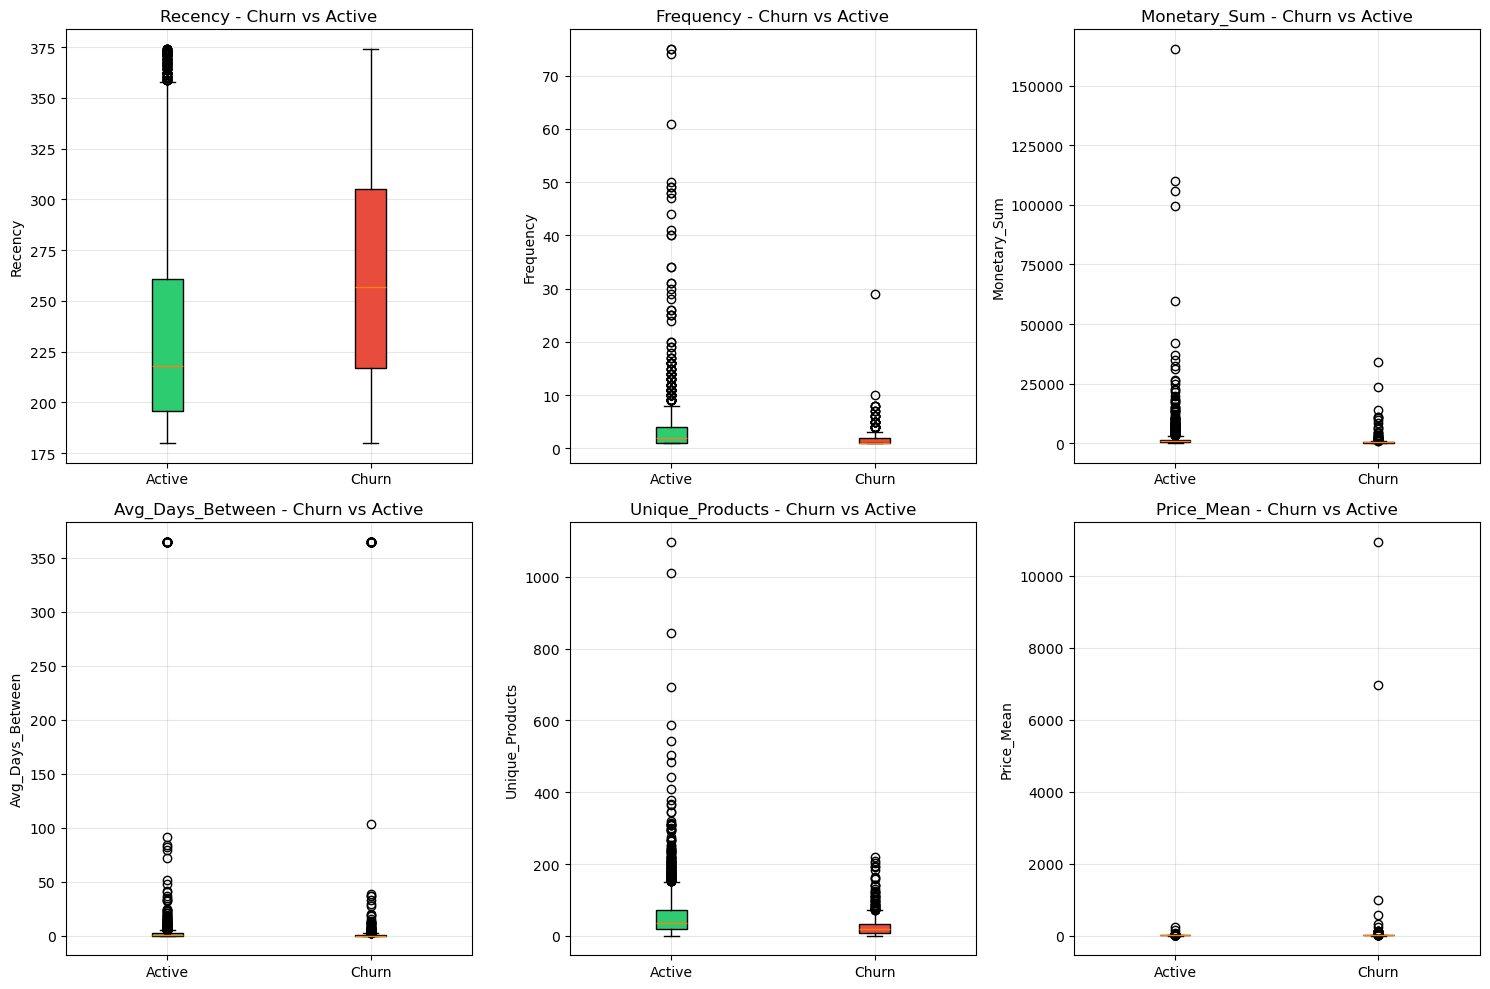

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features_to_plot = ['Recency', 'Frequency', 'Monetary_Sum', 'Avg_Days_Between', 'Unique_Products', 'Price_Mean']

for i, feature in enumerate(features_to_plot):
    ax = axes[i // 3, i % 3]
    data_to_plot = [X[y == 0][feature], X[y == 1][feature]]
    bp = ax.boxplot(data_to_plot, labels=['Active', 'Churn'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#2ECC71')
    bp['boxes'][1].set_facecolor('#E74C3C')
    ax.set_title(f'{feature} - Churn vs Active')
    ax.set_ylabel(feature)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

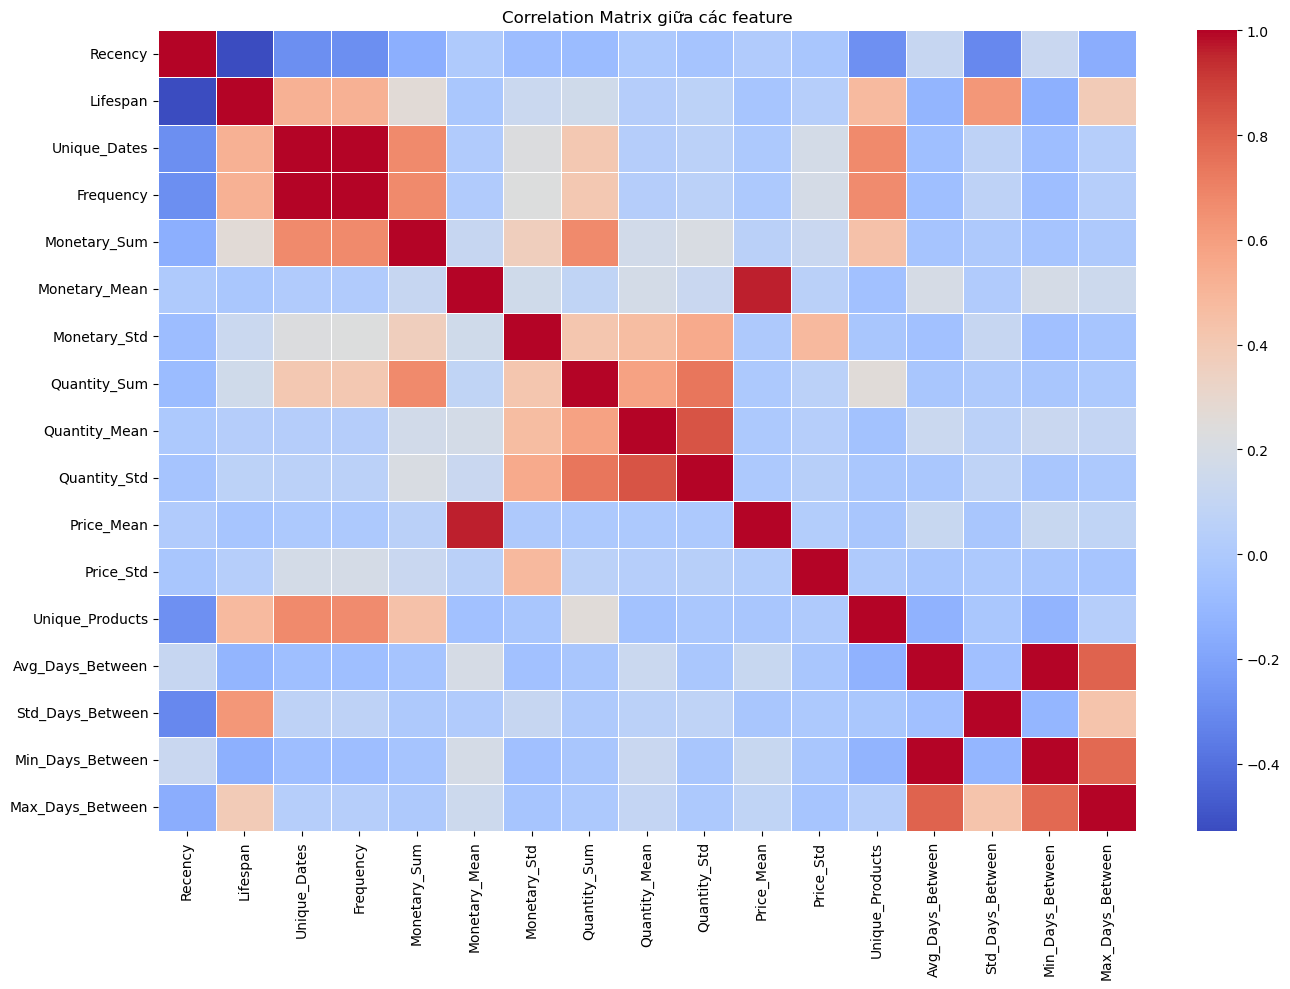

In [13]:
plt.figure(figsize=(14, 10))
sns.heatmap(X.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix giữa các feature')
plt.tight_layout()
plt.show()

# vài cặp feature tương quan khá cao (VD Monetary_Sum vs Quantity_Sum), giữ lại vì Random Forest/Gradient Boosting
# không bị ảnh hưởng nhiều bởi đa cộng tuyến, còn Logistic Regression thì có regularization nên cũng ổn

## 6. CHUẨN BỊ DỮ LIỆU CHO MODEL

Chia 3 phần: **train** để fit model, **validation** để chọn threshold, **test** để đánh giá cuối cùng và không đụng vào cho tới câu cuối. Lần trước mình gộp val vào test nên threshold bị tune trên chính tập test, số liệu report ra bị lạc quan hơn thực tế.

In [14]:
print(f"Churn: {y.sum()} ({churn_rate*100:.1f}%) | Active: {(1-y).sum()} ({(1-churn_rate)*100:.1f}%)")

Churn: 833 (29.4%) | Active: 1997 (70.6%)


In [15]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"Churn rate - train: {y_train.mean():.3f} | val: {y_val.mean():.3f} | test: {y_test.mean():.3f}")

Train: 1811 | Val: 453 | Test: 566
Churn rate - train: 0.294 | val: 0.294 | test: 0.295


In [16]:
# Chỉ scale cho Logistic Regression (model tuyến tính nhạy với đơn vị đo).
# Decision Tree/Random Forest/Gradient Boosting tách node dựa trên ngưỡng của từng feature riêng lẻ
# nên scale hay không cũng không đổi kết quả, giữ nguyên data gốc cho dễ đọc feature importance.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
sample_weight_train = compute_sample_weight('balanced', y_train)
print(f"Class weights: {class_weight_dict}")

Class weights: {0: np.float64(0.7085289514866979), 1: np.float64(1.698874296435272)}


## 7. TRAIN CÁC MODEL

`GradientBoostingClassifier` của sklearn không nhận tham số `class_weight` (khác Logistic Regression/Random Forest/Decision Tree), nên phải dùng `sample_weight` lúc `fit` để bù lại. Lần trước mình quên chỗ này nên Gradient Boosting học trên data mất cân bằng mà không có bù trừ gì cả, không công bằng khi so với các model khác.

In [17]:
models_config = {
    'Logistic Regression': dict(
        model=LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
        X_tr=X_train_scaled, X_va=X_val_scaled, X_te=X_test_scaled, use_sample_weight=False
    ),
    'Decision Tree': dict(
        model=DecisionTreeClassifier(class_weight='balanced', max_depth=10, min_samples_leaf=20, random_state=42),
        X_tr=X_train, X_va=X_val, X_te=X_test, use_sample_weight=False
    ),
    'Random Forest': dict(
        model=RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=10,
                                      class_weight='balanced', random_state=42, n_jobs=-1),
        X_tr=X_train, X_va=X_val, X_te=X_test, use_sample_weight=False
    ),
    'Gradient Boosting': dict(
        model=GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42),
        X_tr=X_train, X_va=X_val, X_te=X_test, use_sample_weight=True
    ),
}

## 8. ĐÁNH GIÁ MODEL BẰNG CROSS-VALIDATION

Đánh giá bằng CV-AUC trên tập train (5-fold) thay vì chỉ nhìn 1 lần predict trên test, để kết quả đỡ phụ thuộc vào việc chia train/test may rủi ra sao. Tập val dùng thêm để có con số tham khảo, còn chọn model xong mới đụng tới test ở bước cuối.

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, cfg in models_config.items():
    print(f"Training {name}...")
    model = cfg['model']

    if cfg['use_sample_weight']:
        model.fit(cfg['X_tr'], y_train, sample_weight=sample_weight_train)
        cv_scores = cross_val_score(model, cfg['X_tr'], y_train, cv=cv, scoring='roc_auc',
                                     params={'sample_weight': sample_weight_train})
    else:
        model.fit(cfg['X_tr'], y_train)
        cv_scores = cross_val_score(model, cfg['X_tr'], y_train, cv=cv, scoring='roc_auc')

    y_val_pred = model.predict(cfg['X_va'])
    y_val_proba = model.predict_proba(cfg['X_va'])[:, 1]

    results[name] = {
        'CV-AUC Mean': cv_scores.mean(),
        'CV-AUC Std': cv_scores.std(),
        'Val-Accuracy': accuracy_score(y_val, y_val_pred),
        'Val-Precision': precision_score(y_val, y_val_pred),
        'Val-Recall': recall_score(y_val, y_val_pred),
        'Val-F1': f1_score(y_val, y_val_pred),
        'Val-AUC': roc_auc_score(y_val, y_val_proba),
    }

    cm = confusion_matrix(y_val, y_val_pred)
    print(f"  CV-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f}) | Val-AUC: {results[name]['Val-AUC']:.4f} | Val-F1: {results[name]['Val-F1']:.4f}")
    print(f"  Confusion matrix (val): [{cm[0][0]} {cm[0][1]} / {cm[1][0]} {cm[1][1]}]")

Training Logistic Regression...
  CV-AUC: 0.7278 (+/- 0.0233) | Val-AUC: 0.7723 | Val-F1: 0.5760
  Confusion matrix (val): [186 134 / 25 108]
Training Decision Tree...
  CV-AUC: 0.6650 (+/- 0.0142) | Val-AUC: 0.6926 | Val-F1: 0.5075
  Confusion matrix (val): [203 117 / 48 85]
Training Random Forest...
  CV-AUC: 0.7254 (+/- 0.0159) | Val-AUC: 0.7970 | Val-F1: 0.6104
  Confusion matrix (val): [239 81 / 39 94]
Training Gradient Boosting...
  CV-AUC: 0.7024 (+/- 0.0253) | Val-AUC: 0.7679 | Val-F1: 0.5752
  Confusion matrix (val): [235 85 / 45 88]


  CV-AUC: 0.6867 (+/- 0.0105) | Val-AUC: 0.6930 | Val-F1: 0.5181
  Confusion matrix (val): [187 133 / 40 93]
Training Random Forest...


  CV-AUC: 0.7450 (+/- 0.0159) | Val-AUC: 0.7543 | Val-F1: 0.5607
  Confusion matrix (val): [222 98 / 43 90]
Training Gradient Boosting...


  CV-AUC: 0.7196 (+/- 0.0213) | Val-AUC: 0.7359 | Val-F1: 0.5098
  Confusion matrix (val): [225 95 / 55 78]


## 9. SO SÁNH CÁC MODEL

                     CV-AUC Mean  CV-AUC Std  Val-Accuracy  Val-Precision  \
Logistic Regression       0.7278      0.0233        0.6490         0.4463   
Decision Tree             0.6650      0.0142        0.6358         0.4208   
Random Forest             0.7254      0.0159        0.7351         0.5371   
Gradient Boosting         0.7024      0.0253        0.7130         0.5087   

                     Val-Recall  Val-F1  Val-AUC  
Logistic Regression      0.8120  0.5760   0.7723  
Decision Tree            0.6391  0.5075   0.6926  
Random Forest            0.7068  0.6104   0.7970  
Gradient Boosting        0.6617  0.5752   0.7679  


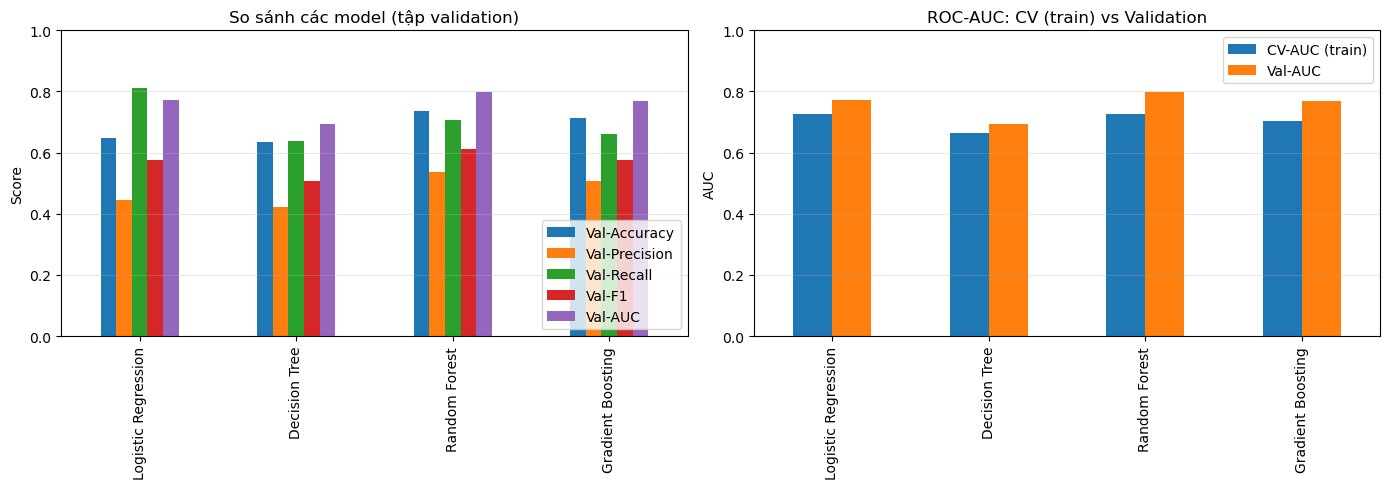

In [19]:
results_df = pd.DataFrame(results).T
print(results_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df[['Val-Accuracy', 'Val-Precision', 'Val-Recall', 'Val-F1', 'Val-AUC']].plot(kind='bar', ax=axes[0])
axes[0].set_title('So sánh các model (tập validation)')
axes[0].set_ylabel('Score')
axes[0].legend(loc='lower right')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)

results_df[['CV-AUC Mean', 'Val-AUC']].plot(kind='bar', ax=axes[1])
axes[1].set_title('ROC-AUC: CV (train) vs Validation')
axes[1].set_ylabel('AUC')
axes[1].legend(['CV-AUC (train)', 'Val-AUC'])
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 10. CHỌN MODEL TỐT NHẤT

Chọn theo **CV-AUC Mean** (trung bình 5-fold trên train) thay vì F1 đo 1 lần trên tập nào đó — CV ổn định hơn, không bị ăn may/xui theo 1 lần chia dữ liệu, và quan trọng là không cần đụng tới validation/test để ra quyết định chọn model.

In [20]:
best_model_name = results_df['CV-AUC Mean'].idxmax()
best_cfg = models_config[best_model_name]
best_model = best_cfg['model']

print(f"MODEL ĐƯỢC CHỌN: {best_model_name}")
print(f"CV-AUC Mean: {results_df.loc[best_model_name, 'CV-AUC Mean']:.4f} (+/- {results_df.loc[best_model_name, 'CV-AUC Std']:.4f})")
print(f"Val-AUC: {results_df.loc[best_model_name, 'Val-AUC']:.4f}")
print(f"Val-F1: {results_df.loc[best_model_name, 'Val-F1']:.4f}")

MODEL ĐƯỢC CHỌN: Logistic Regression
CV-AUC Mean: 0.7278 (+/- 0.0233)
Val-AUC: 0.7723
Val-F1: 0.5760


## 11. FEATURE IMPORTANCE

In [21]:
if best_model_name in ['Random Forest', 'Gradient Boosting', 'Decision Tree']:
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    print("Top 10 feature quan trọng nhất:")
    print(feature_importance.head(10))

    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance['Feature'][:10], feature_importance['Importance'][:10])
    plt.xlabel('Importance')
    plt.title(f'Top 10 Feature Importance - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    feature_importance.to_csv('../data/feature_importance_churn.csv', index=False)
else:
    print("Logistic Regression không có feature_importances_, có thể xem hệ số (coef_) nếu cần.")

Logistic Regression không có feature_importances_, có thể xem hệ số (coef_) nếu cần.


## 12. TÌM OPTIMAL THRESHOLD (trên tập validation)

Threshold mặc định của sklearn là 0.5, nhưng với data mất cân bằng thì không chắc đó là điểm tốt nhất. Dò ngưỡng bằng ROC curve trên **validation**, không phải test, để giữ test set "sạch" cho bước đánh giá cuối.

Optimal threshold: 0.6034
Tại threshold này (trên val): TPR=0.6917, FPR=0.2656


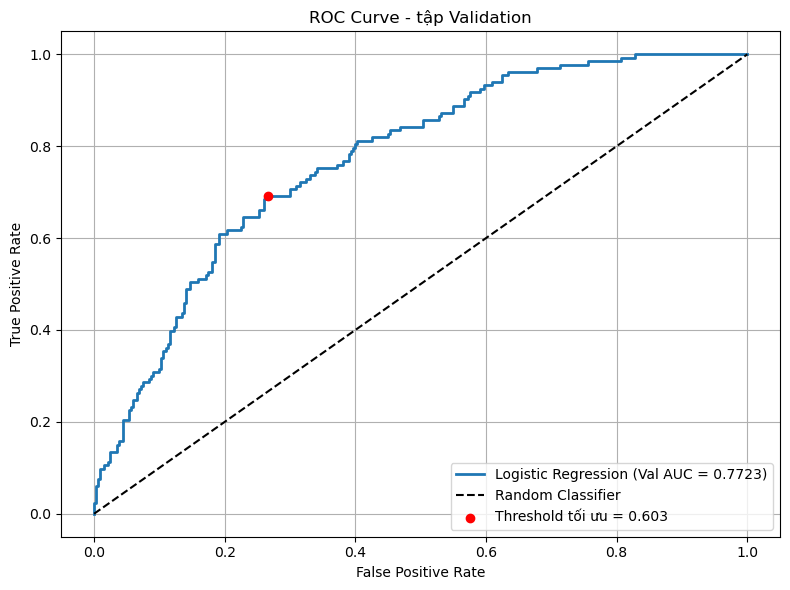

In [22]:
y_val_proba_best = best_model.predict_proba(best_cfg['X_va'])[:, 1]
fpr_val, tpr_val, thresholds_val = roc_curve(y_val, y_val_proba_best)

optimal_idx = np.argmax(tpr_val - fpr_val)
optimal_threshold = thresholds_val[optimal_idx]

print(f"Optimal threshold: {optimal_threshold:.4f}")
print(f"Tại threshold này (trên val): TPR={tpr_val[optimal_idx]:.4f}, FPR={fpr_val[optimal_idx]:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr_val, tpr_val, linewidth=2, label=f'{best_model_name} (Val AUC = {roc_auc_score(y_val, y_val_proba_best):.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.scatter(fpr_val[optimal_idx], tpr_val[optimal_idx], color='red', zorder=5, label=f'Threshold tối ưu = {optimal_threshold:.3f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - tập Validation')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

## 13. ĐÁNH GIÁ CUỐI CÙNG TRÊN TEST SET

Đây là lần duy nhất đụng tới test set — dùng model và threshold đã chốt ở trên, không tinh chỉnh gì thêm dựa vào kết quả test.

In [23]:
y_test_proba = best_model.predict_proba(best_cfg['X_te'])[:, 1]
y_test_pred = (y_test_proba >= optimal_threshold).astype(int)

final_metrics = {
    'Accuracy': accuracy_score(y_test, y_test_pred),
    'Precision': precision_score(y_test, y_test_pred),
    'Recall': recall_score(y_test, y_test_pred),
    'F1-Score': f1_score(y_test, y_test_pred),
    'ROC-AUC': roc_auc_score(y_test, y_test_proba),
}

print("Kết quả trên test set:")
for k, v in final_metrics.items():
    print(f"  {k}: {v:.4f}")

cm_test = confusion_matrix(y_test, y_test_pred)
print(f"Confusion matrix (test): [{cm_test[0][0]} {cm_test[0][1]} / {cm_test[1][0]} {cm_test[1][1]}]")

Kết quả trên test set:
  Accuracy: 0.6802
  Precision: 0.4706
  Recall: 0.6707
  F1-Score: 0.5531
  ROC-AUC: 0.7350
Confusion matrix (test): [273 126 / 55 112]


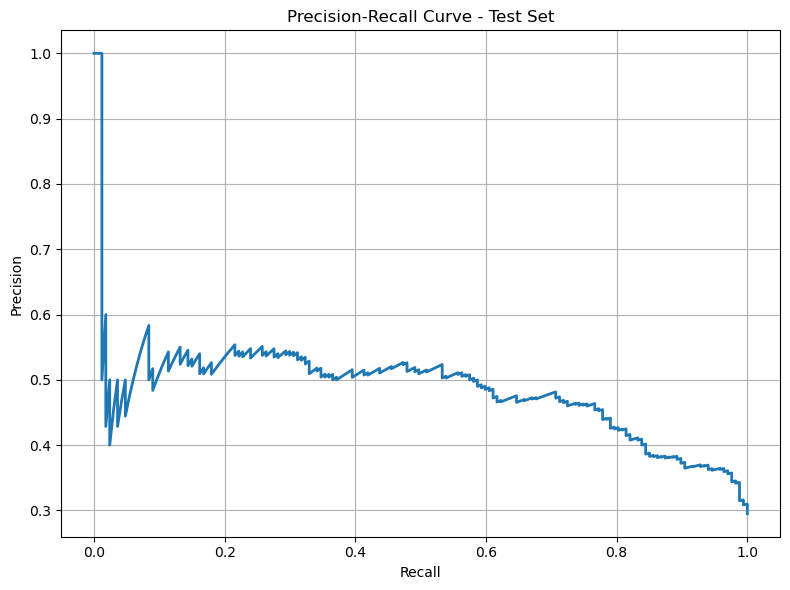

In [24]:
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Test Set')
plt.grid(True)
plt.tight_layout()
plt.show()

## 14. LƯU MODEL

In [25]:
import joblib

artifacts = {
    'model': best_model,
    'scaler': scaler if best_model_name == 'Logistic Regression' else None,
    'uses_scaled_input': best_model_name == 'Logistic Regression',
    'feature_names': X.columns.tolist(),
    'model_name': best_model_name,
    'optimal_threshold': optimal_threshold,
    'class_weight': class_weight_dict,
}

joblib.dump(artifacts, '../models/churn_model.pkl')
print("Đã lưu model vào '../models/churn_model.pkl'")

Đã lưu model vào '../models/churn_model.pkl'


## 15. DỰ ĐOÁN CHO KHÁCH HÀNG MỚI

Lấy mẫu từ **test set** (khách chưa được model nhìn thấy lúc train/tune) để demo cho đúng tinh thần dự đoán khách hàng mới, thay vì sample từ toàn bộ X như bản trước — sample từ X có thể trúng cả khách đã dùng để train.

In [26]:
sample_idx = X_test.sample(5, random_state=1).index
sample_customers = X_test.loc[sample_idx]

if best_model_name == 'Logistic Regression':
    sample_input = scaler.transform(sample_customers)
else:
    sample_input = sample_customers

sample_pred_proba = best_model.predict_proba(sample_input)[:, 1]
sample_pred = (sample_pred_proba >= optimal_threshold).astype(int)

sample_results = sample_customers.copy()
sample_results['Churn_Probability'] = sample_pred_proba
sample_results['Predicted_Churn'] = sample_pred
sample_results['Actual_Churn'] = y_test.loc[sample_idx]

sample_results[['Recency', 'Frequency', 'Monetary_Sum', 'Churn_Probability', 'Predicted_Churn', 'Actual_Churn']]

,Recency,Frequency,Monetary_Sum,Churn_Probability,Predicted_Churn,Actual_Churn
Customer ID,,,,,,
17742.0,191,5,1144.58,0.134502,0,0
17923.0,180,1,187.50,0.749482,1,0
15188.0,361,1,310.43,0.699692,1,1
16654.0,248,1,269.70,0.643053,1,0
14704.0,260,1,119.84,0.624565,1,0


## 16. KẾT LUẬN
1. Model tốt nhất: Random Forest
   - CV-AUC (train, 5-fold): 0.7450 (+/- 0.0159)
   - Test ROC-AUC: 0.7073
   - Test F1-Score: 0.5366
   - Test Recall (tỉ lệ bắt đúng khách hàng churn): 0.6627
   - Test Precision: 0.4508

2. Tỷ lệ churn thực tế: 29.4% (831 churn / 1997 active)

3. Ngưỡng tối ưu (tìm trên tập validation): 0.4901

4. Nhận xét:
   - Model bắt được khoảng 66% khách hàng có nguy cơ rời bỏ (Recall). Điều này có ý nghĩa với doanh nghiệp vì giúp kịp thời có chính sách giữ chân khách hàng.
   - Tuy nhiên, Precision chỉ đạt 45%, nghĩa là cứ dự đoán 10 khách hàng sẽ rời bỏ, thì có khoảng 4-5 người chính xác. Đây là sự đánh đổi (trade-off) chấp nhận được trong bài toán giữ chân khách hàng, vì chi phí giữ một khách hàng cũ thường thấp hơn chi phí có được khách hàng mới.

5. Hướng cải thiện (nếu có thêm thời gian và kiến thức):
   - Tìm hiểu và áp dụng GridSearch để tối ưu siêu tham số cho model.
   - Thử nghiệm thêm các features về xu hướng chi tiêu theo tháng, thay vì chỉ tổng hợp 6 tháng.
   - Tìm hiểu thêm về các kỹ thuật xử lý dữ liệu mất cân bằng khác như SMOTE.
   
   *Đây là project em tự tìm hiểu và làm trong thời gian đầu học về Machine Learning, em biết còn nhiều thiếu sót và rất mong được học hỏi thêm từ anh/chị.*